EDA Cleveland

In [2]:
import pandas as pd
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import numpy as np

Categorical values

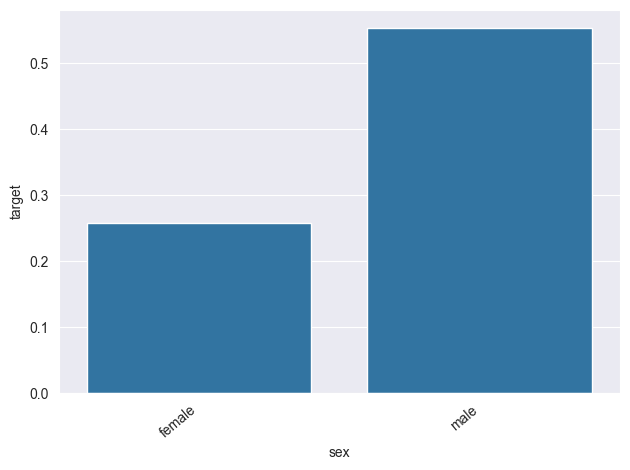

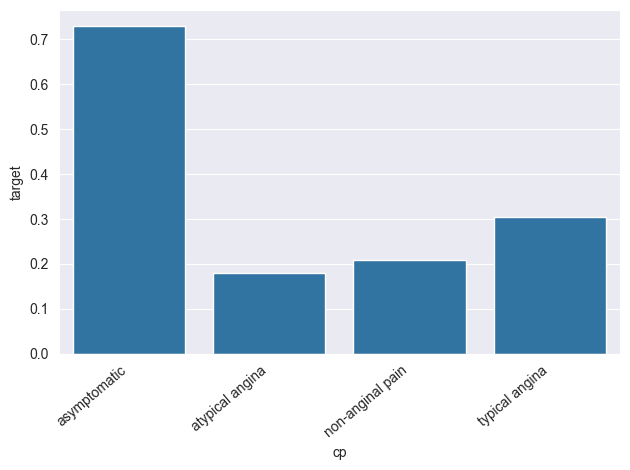

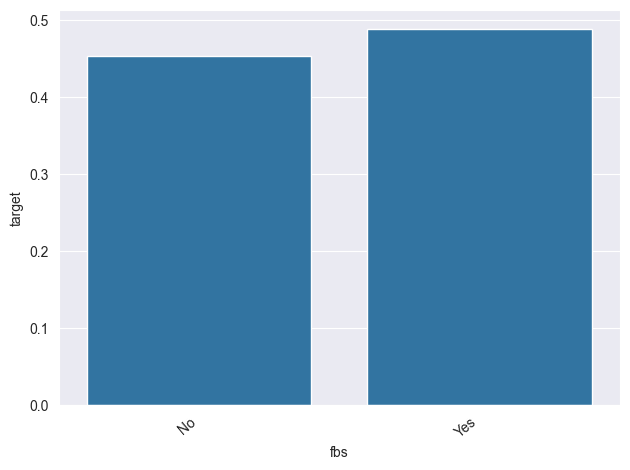

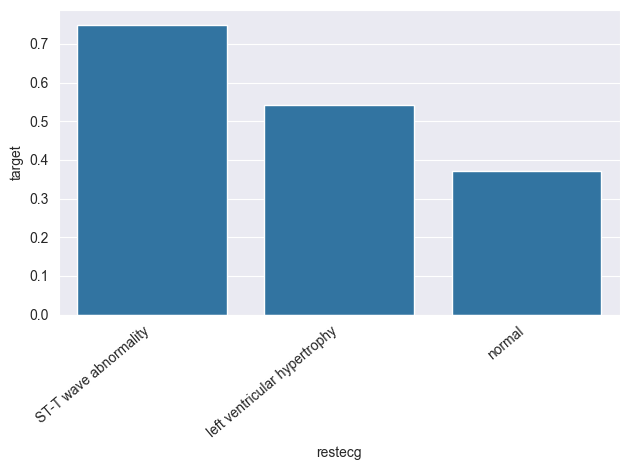

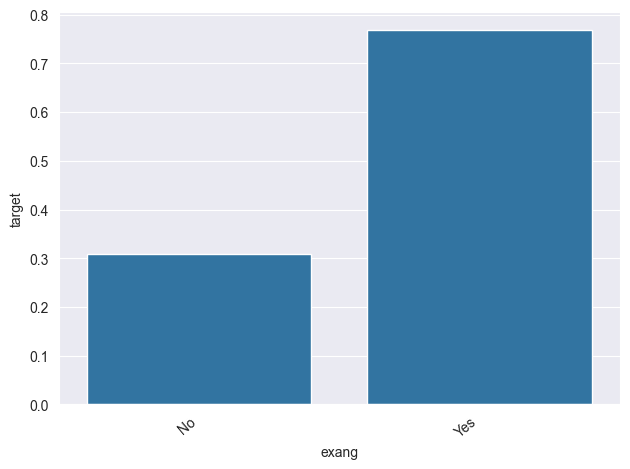

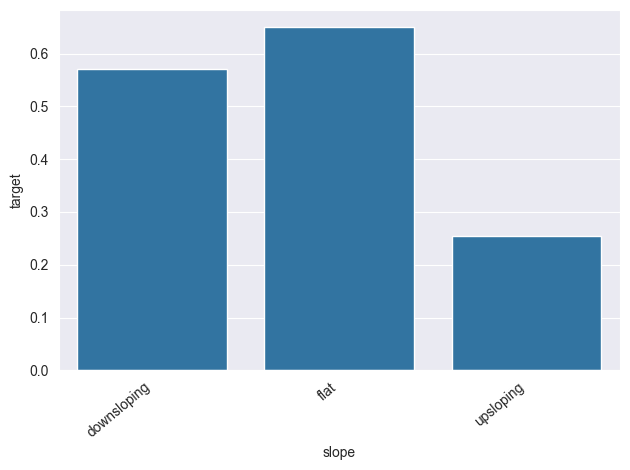

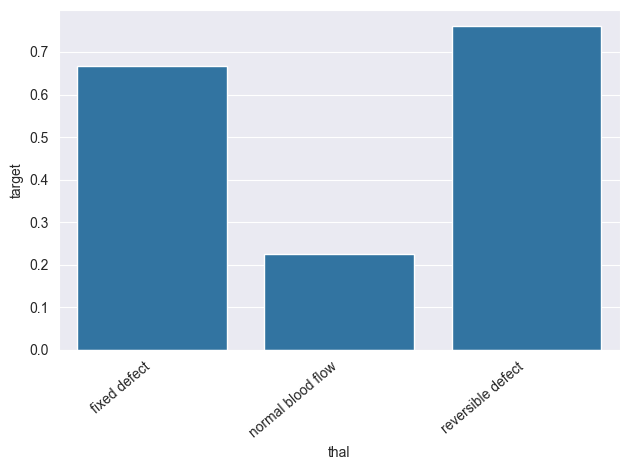

In [5]:
def plot_categorical_data_with_target_rate(df_data: pd.DataFrame, y: str, x: str):
    var = [x, y]
    df_plot = df_data[var].groupby(x).agg("mean").reset_index()
    ax = sns.barplot(x=x, y=y, data=df_plot)
    ax.tick_params(axis="x", labelrotation=40)
    for lab in ax.get_xticklabels():
        lab.set_ha("right")
    plt.tight_layout()
    plt.show()
    plt.close()


df = pd.read_csv(r"../data/processed_cleveland.csv")

def run_categorical_in_loop(df_data: pd.DataFrame, y: str, input_columns: List, ignore_columns: List):
    for col in input_columns:
        if col not in ignore_columns:
            plot_categorical_data_with_target_rate(df, y=y, x=col)


categorical_cols = df.columns[
    df.columns.isin(df._get_numeric_data().columns) == False
]

ignore_categorical = ['target']

run_categorical_in_loop(df, 'target', categorical_cols, ignore_categorical)

Numerical values

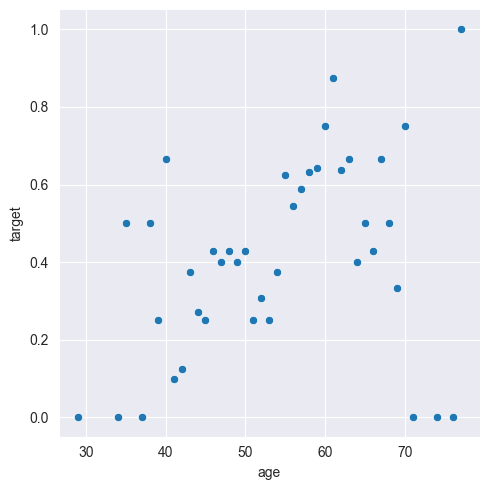

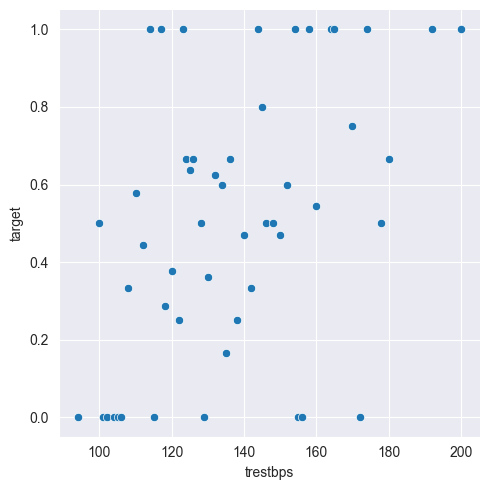

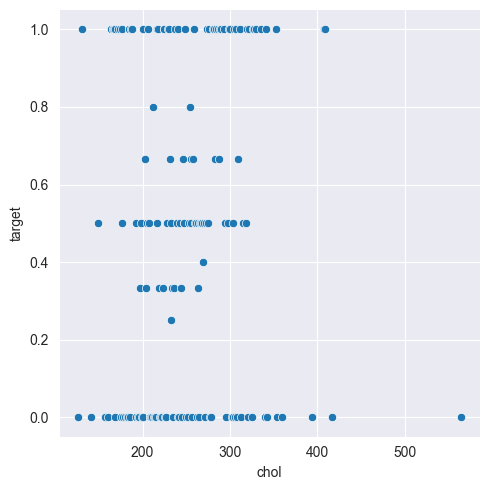

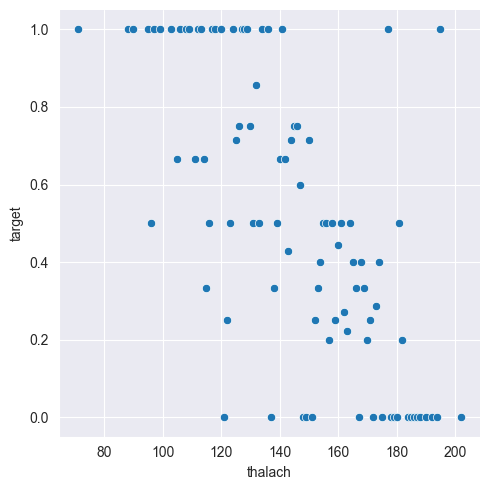

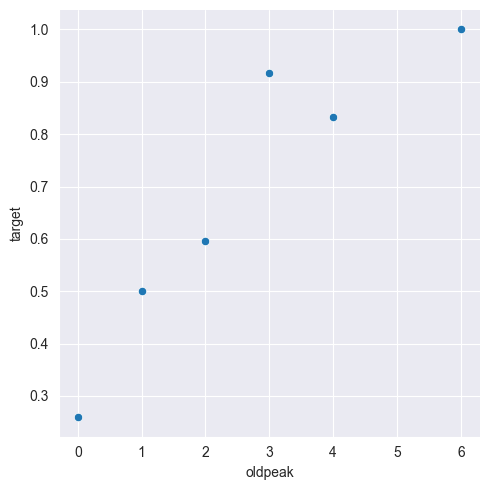

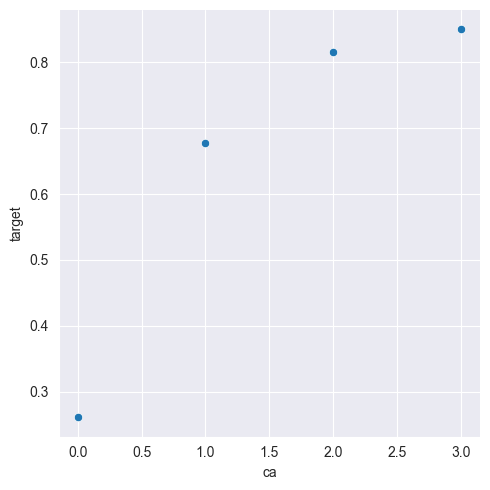

In [6]:
def plot_numeric_data_with_target_rate(df_data: pd.DataFrame, y: str, x: str):
    var = [x, y]
    df_plot = df_data[var].copy()
    df_plot[x] = round(df_plot[x], 0)
    df_plot = df_plot.groupby(x).agg("mean").reset_index()
    ax = sns.relplot(x=x, y=y, data=df_plot)
    plt.tight_layout()
    plt.show()
    plt.close()

def run_numerical_in_loop(df_data: pd.DataFrame, y: str, input_columns: List, ignore_columns: List):
    for col in input_columns:
        if col not in ignore_columns:
            plot_numeric_data_with_target_rate(df, y=y, x=col)

numeric_cols = df.columns[df.columns.isin(df._get_numeric_data().columns) == True]
ignore_list = ['target']
run_numerical_in_loop(df, 'target', numeric_cols, ignore_list)

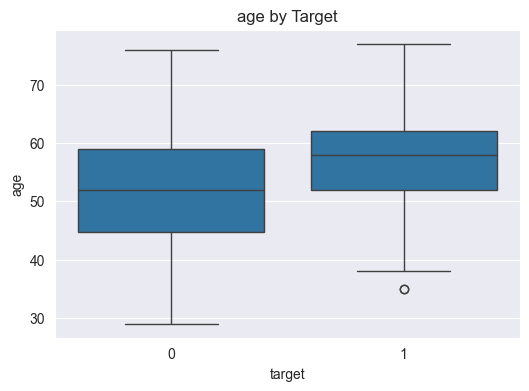

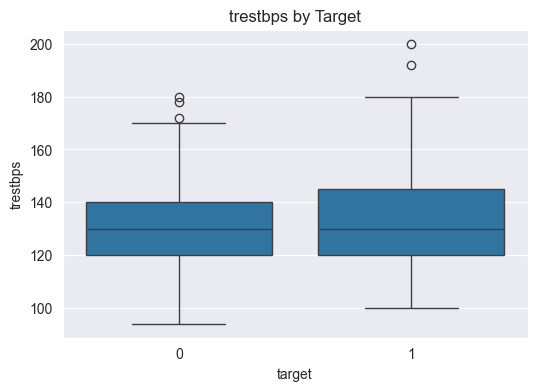

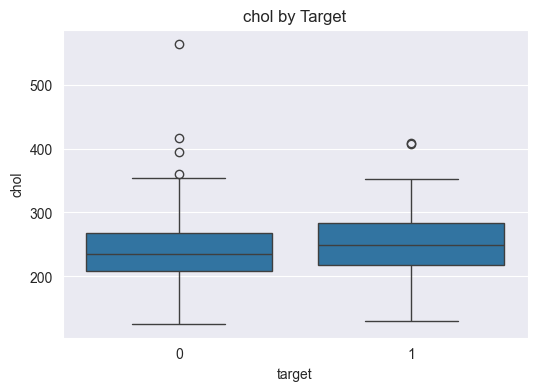

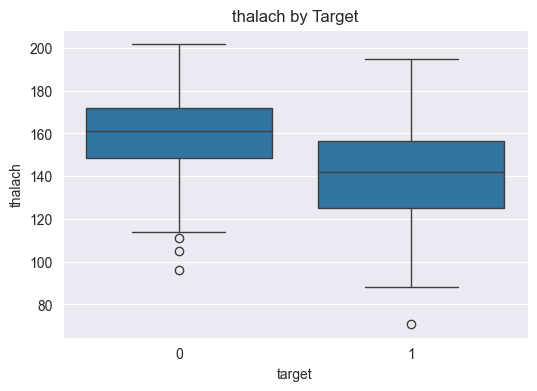

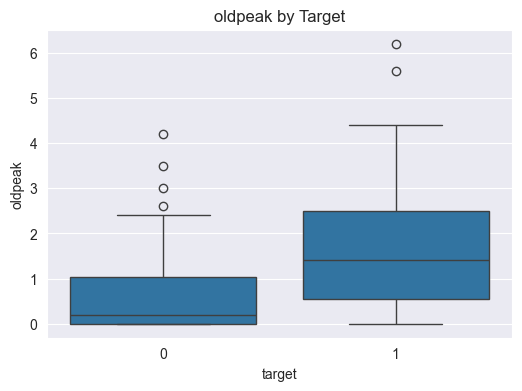

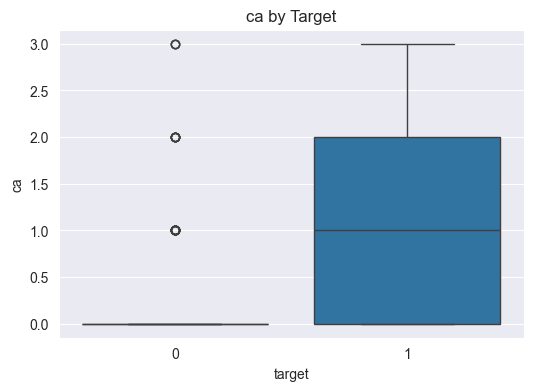

In [7]:
for col in numeric_cols:
    if col != 'target':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='target', y=col, data=df)
        plt.title(f"{col} by Target")
        plt.show()

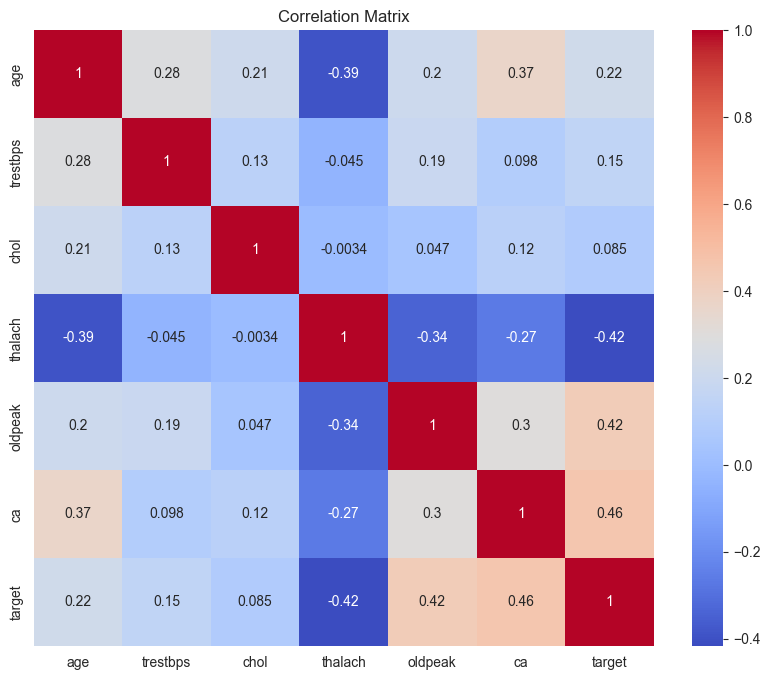

In [8]:
#Korelaciona matrica - zavisnost varijabli
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
#p-value je verovatnoća da dobijena razlika između grupa nastane slučajno
for col in categorical_cols:
    if col != 'target':
        contingency = pd.crosstab(df[col], df['target'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        print(f"{col} - p-value: {p}")

sex - p-value: 2.666712348180942e-06
cp - p-value: 1.2517106007837527e-17
fbs - p-value: 0.7812734067063785
restecg - p-value: 0.006566523814217354
exang - p-value: 1.413788096718085e-13
slope - p-value: 1.1428845467527021e-10
thal - p-value: 1.1098857420294702e-18


In [12]:
for col in numeric_cols:
    if col != 'target':
        group0 = df[df['target'] == 0][col]
        group1 = df[df['target'] == 1][col]
        t_stat, p = ttest_ind(group0, group1)
        print(f"{col} - p-value: {p}")

age - p-value: 8.955636917529706e-05
trestbps - p-value: 0.008548268928594928
chol - p-value: 0.13914167020436527
thalach - p-value: 3.456964908430172e-14
oldpeak - p-value: 1.0976053396984802e-14
ca - p-value: 2.8324882940690685e-17


In [13]:
for col in numeric_cols:
    if col != 'target':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        print(f"{col} - Outliers count:", len(outliers))

age - Outliers count: 0
trestbps - Outliers count: 9
chol - Outliers count: 5
thalach - Outliers count: 1
oldpeak - Outliers count: 5
ca - Outliers count: 20
